# Randome Forest :

#### Pourquoi choisir ce model ?

Le Random Forest est adapté car :

- **Données tabulaires** : Notre dataset est un tableau de stats numériques, c'est exactement le type de données où Random Forest est fort.

- **Déséquilibre des classes** : Les légendaires représentent ~12% du dataset. Le paramètre `class_weight='balanced'` permet de compenser ce déséquilibre sans avoir à modifier le dataset.

- **Relations non-linéaires** : Un légendaire n'est pas défini par une seule stat mais par une combinaison (ex: BST élevé ET Catch Rate faible ET pas de forme alternative). Random Forest capture naturellement ces combinaisons.

- **Feature Importance** : Random Forest nous donnera l'importance de chaque variable, ce qui permet de répondre à la question :
*"Quelles stats définissent vraiment un légendaire ?"*

- **Robuste aux outliers** : Certains Pokémon comme les méga-évolutions ont des stats extrêmes. Random Forest est peu sensible à ces valeurs extrêmes.

## 1. Import et cargements des donées

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


## 2. Recuperation des données

On separe les données du DataFrame en deux catégories :
- **X** : Toutes les colonnes (les statistiques)  qui servent à prédire
- **Y** : Ce qu'on veut prédire, c'est a dire estce que c'est un legendaire ?

Puis on les sépare en données d'entraînement et de test :
- **X_train / y_train** : Ce sont les données  d'entrainement
- **X_test / y_test** : Ce sont les données sur laquelle le modeles sera évalué

In [2]:
# On recupere les donnée preprocessées
from Prepro import prepare_data  

# On charge les données nettoyées et on prépare les données d'entraînement et de test
df_clean = pd.read_csv("../../data/processed/pokemon_clean.csv")
X_train, X_test, y_train, y_test, preprocessor = prepare_data(df_clean)


              precision    recall  f1-score   support

      Normal       0.88      1.00      0.94       182
  Légendaire       0.00      0.00      0.00        25

    accuracy                           0.88       207
   macro avg       0.44      0.50      0.47       207
weighted avg       0.77      0.88      0.82       207



c:\Users\Romane\Documents\Esigelec_cours\cours_s8\DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Romane\Documents\Esigelec_cours\cours_s8\DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Romane\Documents\Esigelec_cours\cours_s8\DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

## 3. Entrainement du modéle

### 3.1 On cherche les meilleurs parametre pour entrainer le model

Pour ca on uttilise ``GridSearch``

On le parametre avec :
- cv=5 : il coupe les donnée train en 5 parties et teste chaque combinaison 5 fois
- scoring='f1' : on évalue sur le F1 et pas l'accuracy car on a peu de légendaires


In [4]:
from sklearn.pipeline import make_pipeline

param_grid = {
    'randomforestclassifier__n_estimators': [100, 200, 300], # nombre d'arbre
    'randomforestclassifier__max_depth': [None, 10, 20, 30], # profondeur maximale de chaque arbre
    'randomforestclassifier__min_samples_split': [2, 5, 10]  # nombre minimum d'échantillons pour diviser un nœud
}

grid_search = GridSearchCV(
    make_pipeline(preprocessor, RandomForestClassifier(class_weight='balanced', random_state=42)),
    param_grid,
    cv=5,          # validation croisée en 5 parties
    scoring='f1',  # on optimise sur le F1 car jeux de données déséquilibrées
    n_jobs=-1      # parametre technique : utilise tous les coeurs du processeur (de l'ordinateur qui execute) pour aller plus vite
)

grid_search.fit(X_train, y_train)
print("Meilleurs paramètres :", grid_search.best_params_)

Meilleurs paramètres : {'randomforestclassifier__max_depth': None, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__n_estimators': 300}


Les meilleurs parametre d'apres ``GridSearch`` :
- ``max_depth: None`` = les arbres peuvent pousser sans limite de profondeur. Ça signifie que les frontières entre légendaires et non-légendaires sont complexes, une profondeur limitée ne suffirait pas.
- ``min_samples_split: 10`` = il faut au moins 10 échantillons pour diviser un nœud. C'est une valeur plutôt haute, ce qui signifie que le modèle évite de trop se spécialiser sur les données d'entraînement (évite l'overfitting), important car les légendaires sont peu nombreux.
- ``n_estimators: 300`` = le maximum qu'on a testé a été choisi, ce qui suggère que plus il y a d'arbres, mieux c'est pour ce dataset. On aurait pu tester plus haut mais 300 est déjà un bon compromis temps/performance.

### 3.2 On entraine le model

In [7]:
# Extraction des meilleurs paramètres pour les passer au modèle final
best_params = {}
for k, v in grid_search.best_params_.items():
    nouvelle_cle = k.replace('randomforestclassifier__', '')
    best_params[nouvelle_cle] = v
# k = la clé, par exemple 'randomforestclassifier__max_depth'
# v = la valeur, par exemple None
# .replace('randomforestclassifier__', '') supprime le préfixe → donne 'max_depth'

# Entraînement du modèle avec les meilleurs paramètres
rf = make_pipeline(
    preprocessor, # on réutilise le preprocessor pour s'assurer que les données sont transformées de la même manière que lors du GridSearch
    RandomForestClassifier(
        **best_params, # on utilise les meilleurs paramètres trouvés par le GridSearch
        class_weight='balanced',
        random_state=42
    )
)

# Entraînement du modèle et prédiction
rf.fit(X_train, y_train)

# Prédiction sur les données de test
y_pred = rf.predict(X_test)


``class_weight='balanced'`` : compense le fait qu'on a peu de légendaires

``rf.fit()`` : c'est ici que le modèle apprend à partir de X_train et y_train

## 4. Evaluation

### 4.1 Matrice de confusion

Matrice de confusion pour évaluer les performances du modèle en termes de vrais positifs, faux positifs, vrais négatifs et faux négatifs

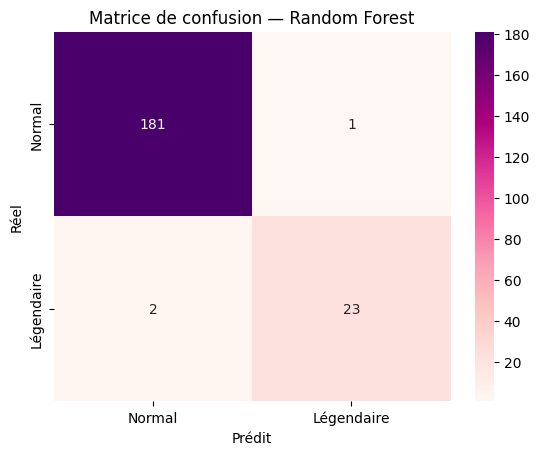

Légendaires correctement identifiés : 23/25 (92.0%)


In [11]:
# Matrice de confusion
matrice_confusion = confusion_matrix(y_test, y_pred)
sns.heatmap(matrice_confusion, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Normal', 'Légendaire'],
            yticklabels=['Normal', 'Légendaire'])
plt.title("Matrice de confusion — Random Forest")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.show()

# Taux de reconnaissance des légendaires
vrais_legendaires = confusion_matrix(y_test, y_pred)[1, 1]  # case (Légendaire, Légendaire)
total_legendaires = confusion_matrix(y_test, y_pred)[1, :].sum()  # toute la ligne Légendaire
print(f"Légendaires correctement identifiés : {vrais_legendaires}/{total_legendaires} ({vrais_legendaires/total_legendaires*100:.1f}%)")


On observe qu'il y a :
- 181 : Pokémon normaux correctement identifiés
- 23 : Pokémon légendaires correctement identifiés 
- 1 : Un Pokémon normal classé à tort comme légendaire  (faux positif)
- 2 : Deux légendaires classés à tort comme normaux  (faux négatif)

On peut dire que le modèle est très performant. Sur 207 Pokémon de test, il n'en rate que 3.  Il en reconnaît 23 sur 25, soit 92% d'entre eux.

### 4.2 Classification Report

Rapport de classification pour évaluer les performances du modèle en termes de précision, sensibilité et F1-score

In [9]:
print(classification_report(y_test, y_pred, target_names=['Normal', 'Légendaire']))

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       182
  Légendaire       0.96      0.92      0.94        25

    accuracy                           0.99       207
   macro avg       0.97      0.96      0.97       207
weighted avg       0.99      0.99      0.99       207



On observe que :
- Accuracy = 99% sur 207 Pokémon : il en rate 3, c'est excellent.
- Precision = 96% sur les légendaires : quand il dit "c'est un légendaire", il a raison 96% du temps
- Recall = 92% sur les légendaires : il retrouve 92% de tous les légendaires réels
- F1 = 94% sur les légendaires : bon équilibre entre les deux

### 4.3 Les colonnes importantes

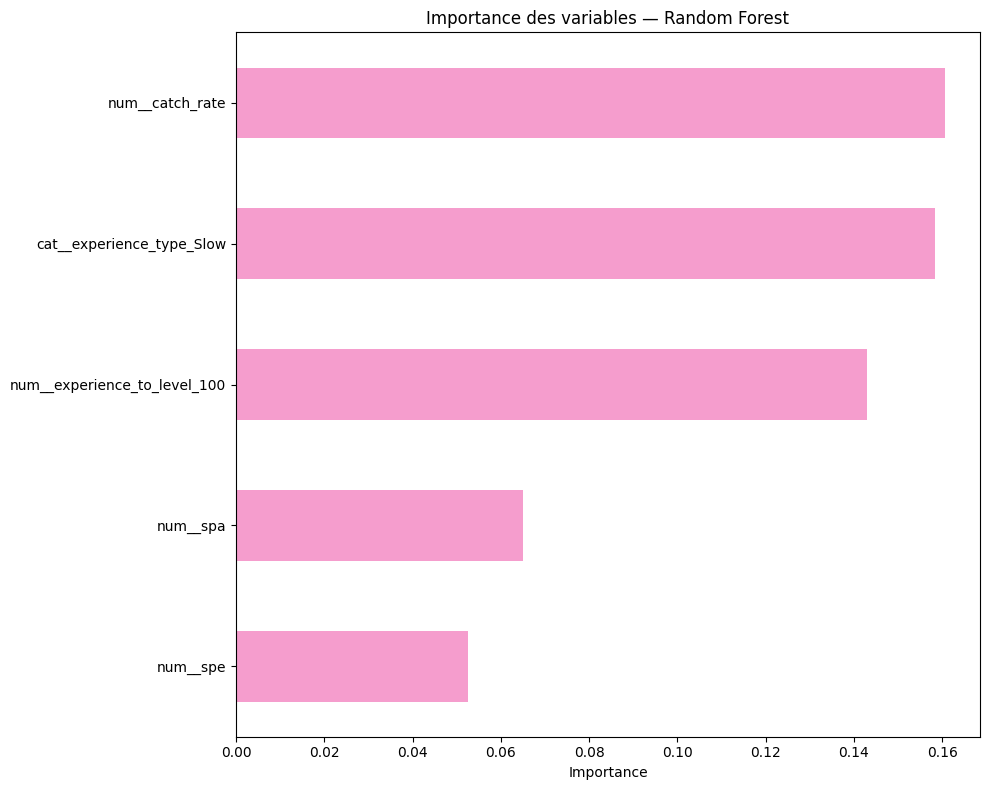

In [20]:
# Calcul de l'importance des variables
rf_model = rf.named_steps['randomforestclassifier'] # on récupère le modèle de Random Forest à partir du pipeline pour accéder à ses attributs
feature_names = rf.named_steps['columntransformer'].get_feature_names_out() # on récupère les noms des features après transformation (ex: après OneHotEncoding, etc.)

importances = pd.Series(rf_model.feature_importances_, index=feature_names) # on crée une série pandas pour associer chaque importance à son nom de feature
importances = importances.sort_values(ascending=True).tail(5) # on trie les importances pour les afficher de manière plus lisible (les plus importantes en bas)

# Visualisation 
importances.plot(kind='barh', color="#f59dcd", figsize=(10, 8))
plt.title("Importance des variables — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

``rf.`` = cherche à l'intérieur du pipeline 

``named_steps`` = un attribut de Pipeline qui te permet d'accéder à chaque étape du pipeline par son nom

``get_feature_names_out()`` = retourne la liste de toutes les colonnes après transformation 

On observe que :
- ``num__catch_rate`` = ~0.16 : le taux de capture est la stat la plus discriminante. Les légendaires ont un catch rate très bas, c'est a dire qu'il sont plus difficile a capturer.
- ``cat__experience_type_Slow`` = ~0.16 : les légendaires ont presque tous une courbe d'expérience "Slow", c'est a dire qu'il faut beaucoup plus d'XP pour monter en niveau comparé au autres Pokemon
- ``num__experience_to_level_100`` = ~0.14 : lié au point précédent, les légendaires nécessitent beaucoup d'XP pour atteindre le niveau 100
- ``num__spa`` = ~0.065 : l'Attaque Spéciale, les légendaires ont tendance à avoir des stats élevées
- ``num__spe`` = ~0.053 : la Vitesse, même logique

## Conclusion

Le Random Forest atteint une accuracy de 99% et un F1 de 94% sur les légendaires, malgré le déséquilibre du dataset (~12% de légendaires). Le modèle s'appuie principalement sur des caractéristiques mécaniques du jeu (catch_rate, courbe d'expérience, XP nécessaire) plutôt que sur les stats de combat brutes, ce qui reflète une logique cohérente avec l'univers Pokémon : les légendaires sont conçus pour être rares et difficiles à obtenir, pas seulement puissants au combat.

Sur 25 légendaires dans le jeu de test, 23 ont été correctement identifiés — les 2 ratés sont probablement des légendaires atypiques.

Pour ameliorer le model on pourrait essayer de : 
- Tester des valeurs de n_estimators plus élevées (400, 500) dans le GridSearch, 
- Ajuster le seuil de décision (par défaut 0.5) pour que le modèle soit moins strict et détecte davantage de légendaires, au risque d'en classer quelques normaux comme légendaires par erreur
- Ajouter des colonnes comme : 'total des stats' pour aider le model